# **07. Model Evaluation**

### **Introduction**

Multiple baseline machine learning models were trained and evaluated using the ROC-AUC score. The best-performing model was selected for hyperparameter tuning using GridSearchCV. The optimized model was then retrained with the best parameters and evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.


In [17]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
import time
from pathlib import Path
import pickle
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)



In [2]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.display import display, Markdown

def display_md(string):
    display(Markdown(string))
    

## **1. Loading Preprocessed Model Data**

In [24]:
# define path for best model and base_model
parent_path = Path.cwd().parent
best_model_path = parent_path.joinpath('models', 'best_model.pkl')

base_model_path = parent_path.joinpath('models', 'logistic_regression_model.pkl')


In [11]:
display_md("**Loading Best & Base Model Data....**")
with open(best_model_path, 'rb') as file:
    best_model_data = joblib.load(file)
    
with open(base_model_path, 'rb') as file:
    base_model_data = joblib.load(file)
    

**Loading Best & Base Model Data....**

In [5]:
best_model_data.keys()

dict_keys(['model', 'best_pipeline', 'selected_features', 'full_preprocessed_train', 'y_train', 'full_preprocessed_test', 'y_test'])

In [6]:
# Load the best model and its components
best_model = best_model_data['model']
best_model_pipeline = best_model_data['best_pipeline']
selected_features = best_model_data['selected_features']
X_train = best_model_data['full_preprocessed_train']
X_test = best_model_data['full_preprocessed_test']
y_train = best_model_data['y_train']
y_test = best_model_data['y_test']
X_train_new = X_train[selected_features]
X_test_new = X_test[selected_features]


## **2. Hyperparameter Tuning for XGBoost Classifier**

In [7]:
# store tuning results in list
tuning_results = []

# Initialize the XGBClassifier
xgb_model_pipeline = best_model_pipeline

# Define parameters grid
parameters_dict = {
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__gamma': [0.5, 1, 1.5, 2, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],       # fraction of samples to be used for fitting the individual base learners
    'classifier__colsample_bytree': [0.6, 0.8, 1.0], # fraction of features to be used for fitting the individual base learners
    'classifier__max_depth': [3, 4, 5]
}

# Set up stratified k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model_pipeline,
    param_grid=parameters_dict,
    scoring='roc_auc',
    n_jobs=-1,
    cv=kfold,
    verbose=1
)

# Measuring training time
start_time = time.time()
# Fit the model
grid_search.fit(X_train_new, y_train)
end_time = time.time()
training_time = end_time - start_time

# Get the best parameters , best score and best pipeline
best_model_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

display_md(f"**Best Parameters: {best_params}**")
display_md(f"**Best ROC AUC Score: {best_score}**")
display_md(f"**Training Time: {training_time} seconds**")

tuning_results.append({
    'model': best_model,
    'best_params': best_params,
    'best_roc_auc_score': best_score,
    'training_time': training_time
})

# Save the tuning results as dataframe
tuning_results_df = pd.DataFrame(tuning_results)


Fitting 5 folds for each of 405 candidates, totalling 2025 fits


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:24:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 2, 'classifier__max_depth': 4, 'classifier__min_child_weight': 10, 'classifier__subsample': 1.0}**

**Best ROC AUC Score: 0.9295482126066303**

**Training Time: 559.9456884860992 seconds**

## **3. Selecting Final Model & Saving**

In [8]:
display(tuning_results_df)

display_md(f"**=== BEST MODEL ===**")
print(f"Best Model : {tuning_results_df['model'].iloc[0]}")  # Display the best model  
print(f"Best Parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

try:
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)
    cv_results = cross_validate(xgb_model_pipeline, X_train_new, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_accuracy_prev = cv_results['test_accuracy'].mean()
    cv_precision_prev = cv_results['test_precision'].mean()
    cv_recall_prev = cv_results['test_recall'].mean()
    cv_f1_prev = cv_results['test_f1'].mean()
    cv_roc_auc_prev = cv_results['test_roc_auc'].mean()

    improvement = best_score - cv_roc_auc_prev
    percent_improvement = (improvement / cv_roc_auc_prev) * 100 if cv_roc_auc_prev != 0 else 0

    print(f"Basline ROC AUC Score (from cross-validation): {cv_roc_auc_prev:.4f}")
    print(f"Tuned Model ROC AUC Score: {best_score:.4f}")
    print(f"Improvement : {improvement:.4f} ({percent_improvement:.2f}%)")

except Exception as e:
    print(f"\nNo best model found. Error: {e}")


,model,best_params,best_roc_auc_score,training_time
0,xgboost,"{'classifier__colsample_bytree': 0.8, 'classif...",0.929548,559.945688


**=== BEST MODEL ===**

Best Model : xgboost
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 2, 'classifier__max_depth': 4, 'classifier__min_child_weight': 10, 'classifier__subsample': 1.0}
Best ROC AUC Score: 0.9295482126066303
Basline ROC AUC Score (from cross-validation): 0.9211
Tuned Model ROC AUC Score: 0.9295
Improvement : 0.0085 (0.92%)


In [9]:
best_model_pipeline = grid_search.best_estimator_

# Save the final best model in .pkl file for furthur use
model_dir = parent_path.joinpath("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define file path inside ,odel directory
final_model_file = model_dir.joinpath("final_tuned_model.pkl")

# Save the final tuned model
with open(final_model_file, 'wb') as f:
    joblib.dump(best_model_pipeline, f)

print("Final tuned model saved successfully!!!!")


Final tuned model saved successfully!!!!


In [25]:
# Load back the fined-tuned model to verify
with open(final_model_file, 'rb') as file:
    final_tuned_pipeline = joblib.load(file)


## **4. Model Evaluation Using Accuracy, Precision, F1-Score, ROC-AUC**

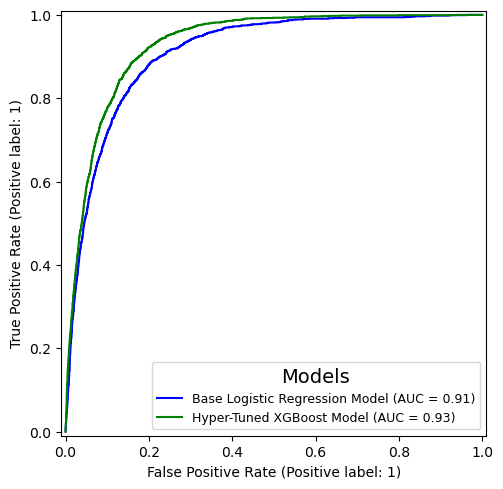

In [ ]:

base_pipeline = base_model_data
final_pipeline = final_tuned_pipeline

# Visualization of ROC Curve for both base and tuned model
fig, ax = plt.subplots(figsize=(15, 5))

# base logistic regression model
RocCurveDisplay.from_estimator(base_pipeline, X_test_new[base_pipeline.feature_names_in_], y_test, ax=ax, name="Base Logistic Regression Model", color='blue')

# tuned XGBoost model
RocCurveDisplay.from_estimator(final_pipeline, X_test_new, y_test, ax=ax, name='Hyper-Tuned XGBoost Model', color='green')

# legend and title
ax.legend(loc='lower right', title='Models', fontsize=9, title_fontsize=14)

plt.tight_layout()
plt.show()



In [39]:
tuning_result_df

NameError: name 'tuning_result_df' is not defined